In [10]:
# CELL 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import sqlite3
import os

DB_PATH = "../data/patents.db"
VISUALS_DIR = "../visuals/"
REPORTS_DIR = "../reports/"

conn = sqlite3.connect(DB_PATH)

print("Libraries loaded!")

Libraries loaded!


In [11]:
# CELL 2 - Load Data from Database
df_inventors = pd.read_sql("SELECT * FROM inventors", conn)
df_patents = pd.read_sql("SELECT * FROM patents", conn)

print(f"Patents loaded:   {len(df_patents):,} rows")
print(f"Inventors loaded: {len(df_inventors):,} rows")

Patents loaded:   100,000 rows
Inventors loaded: 100,000 rows


In [12]:
# CELL 3 - Prepare Data for ML
# count patents per inventor
df_inv_counts = df_inventors.groupby('inventor_id')['patent_id'].count().reset_index()
df_inv_counts.columns = ['inventor_id', 'patent_count']

# add inventor details
df_inv_counts = df_inv_counts.merge(
    df_inventors[['inventor_id','full_name','country']].drop_duplicates('inventor_id'),
    on='inventor_id',
    how='left'
)

print(f"Inventor counts prepared: {len(df_inv_counts):,} rows")
print(df_inv_counts.head())

Inventor counts prepared: 92,442 rows
                 inventor_id  patent_count           full_name country
0  0000n8nqsxhrztn7djlxou00k             1        Muamer Zukic      US
1  0004z0eq002iqz3t9ecx7l5ml             1        Paul Barberi      FR
2  000c0a89h3umx2083c1fhf6sc             1  Arthur R. Stennett      US
3  000f0k6brgval6kr9agzjlgcg             1   Lynda M. Salvetti      US
4  000f3mi5t5lpa1ch45ncsfqtz             1     Semion H. Mazor      IL


In [13]:
# CELL 4 - Create Productivity Categories
def categorize(count):
    if count >= 10:
        return 2   # High
    elif count >= 3:
        return 1   # Medium
    else:
        return 0   # Low

df_inv_counts['productivity'] = df_inv_counts['patent_count'].apply(categorize)
df_inv_counts['productivity_label'] = df_inv_counts['productivity'].map({
    0: 'Low',
    1: 'Medium',
    2: 'High'
})

print("Productivity distribution:")
print(df_inv_counts['productivity_label'].value_counts())

Productivity distribution:
productivity_label
Low       91445
Medium      982
High         15
Name: count, dtype: int64


In [14]:
# CELL 5 - Train Linear Regression Model
# feature: patent count
# target: productivity category
X = df_inv_counts[['patent_count']]
y = df_inv_counts['productivity']

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
model = LinearRegression()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)
y_pred_rounded = np.round(y_pred).clip(0, 2).astype(int)

print(f"Training samples:  {len(X_train):,}")
print(f"Testing samples:   {len(X_test):,}")
print(f"R2 Score:          {r2_score(y_test, y_pred):.4f}")
print(f"Mean Abs Error:    {mean_absolute_error(y_test, y_pred):.4f}")

Training samples:  73,953
Testing samples:   18,489
R2 Score:          0.5237
Mean Abs Error:    0.0202


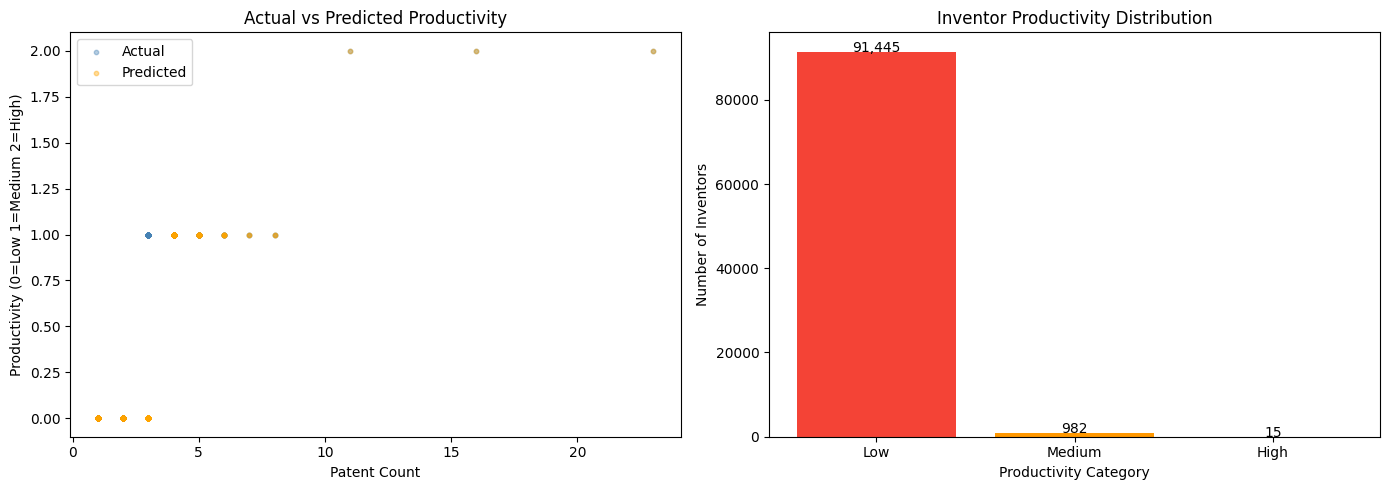

Chart saved: ml_productivity.png


In [15]:
# CELL 6 - Visualize Model Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Actual vs Predicted
axes[0].scatter(X_test, y_test, color='steelblue', alpha=0.4, label='Actual', s=10)
axes[0].scatter(X_test, y_pred_rounded, color='orange', alpha=0.4, label='Predicted', s=10)
axes[0].set_xlabel("Patent Count")
axes[0].set_ylabel("Productivity (0=Low 1=Medium 2=High)")
axes[0].set_title("Actual vs Predicted Productivity")
axes[0].legend()

# Chart 2 - Productivity Distribution
labels = ['Low', 'Medium', 'High']
counts = df_inv_counts['productivity_label'].value_counts()
colors = ['#F44336', '#FF9800', '#4CAF50']
axes[1].bar(labels, [counts.get('Low',0), counts.get('Medium',0), counts.get('High',0)], color=colors)
axes[1].set_xlabel("Productivity Category")
axes[1].set_ylabel("Number of Inventors")
axes[1].set_title("Inventor Productivity Distribution")

for i, v in enumerate([counts.get('Low',0), counts.get('Medium',0), counts.get('High',0)]):
    axes[1].text(i, v + 10, f"{v:,}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(VISUALS_DIR + "ml_productivity.png", dpi=150)
plt.show()
print("Chart saved: ml_productivity.png")

In [16]:
# CELL 7 - Predict New Inventors
print("PRODUCTIVITY PREDICTIONS FOR NEW INVENTORS")
print("="*50)

test_cases = [1, 3, 5, 10, 20, 36]

for patents in test_cases:
    pred = model.predict(pd.DataFrame({'patent_count': [patents]}))[0]
    pred_rounded = int(np.round(pred).clip(0, 2))
    label = {0: 'Low', 1: 'Medium', 2: 'High'}[pred_rounded]
    print(f"Inventor with {patents:>3} patents → Productivity: {label}")

PRODUCTIVITY PREDICTIONS FOR NEW INVENTORS
Inventor with   1 patents → Productivity: Low
Inventor with   3 patents → Productivity: Low
Inventor with   5 patents → Productivity: Medium
Inventor with  10 patents → Productivity: High
Inventor with  20 patents → Productivity: High
Inventor with  36 patents → Productivity: High


In [17]:
# CELL 8 - Save ML Results
df_ml_results = df_inv_counts[['full_name','country','patent_count','productivity_label']].copy()
df_ml_results = df_ml_results.sort_values('patent_count', ascending=False)
df_ml_results.to_csv(REPORTS_DIR + "ml_productivity.csv", index=False)

print("ML results saved to reports/ml_productivity.csv")
print(f"Total inventors classified: {len(df_ml_results):,}")
print("")
print("Sample results:")
print(df_ml_results.head(10).to_string(index=False))

ML results saved to reports/ml_productivity.csv
Total inventors classified: 92,442

Sample results:
            full_name country  patent_count productivity_label
     Shunpei Yamazaki      JP            36               High
      Kia Silverbrook      AU            23               High
              Tao Luo      US            16               High
             Junyi Li      US            13               High
     Bartley K. Andre      US            12               High
   Duncan Robert Kerr      US            11               High
Matthew Dean Rohrbach      US            11               High
     Gurtej S. Sandhu      US            11               High
             Jing Sun      US            11               High
 Peter Russell-Clarke      US            10               High


In [18]:
# CELL 9 - Close Connection
conn.close()
print("07_ml_analysis.ipynb complete!")
print("")
print("MODEL SUMMARY")
print("="*40)
print("Model:     Linear Regression")
print("Feature:   Patent Count per Inventor")
print("Target:    Productivity Category")
print("Classes:   Low / Medium / High")
print("")
print("Files saved:")
print("  visuals/ml_productivity.png")
print("  reports/ml_productivity.csv")

07_ml_analysis.ipynb complete!

MODEL SUMMARY
Model:     Linear Regression
Feature:   Patent Count per Inventor
Target:    Productivity Category
Classes:   Low / Medium / High

Files saved:
  visuals/ml_productivity.png
  reports/ml_productivity.csv
